
### B Vidakovic Quantum Framework for Wavelet Shrinkage
## Example 3

## Qiskit 2.x demo: Haar (length 8) as a Givens-based wavelet transform
### and verification on y = (1, 0, -3, 2, 1, 0, 1, 2)

This notebook contains two versions of the Givens-based Haar transform.
In the first approach, the full Givens Har matrix $W$ is computed classically and applied to the quantum state as a single unitary gate.
In the second approach, the same transformation is implemented modularly by decomposing it into basic quantum operations, specifically, single-qubit rotation gates and CNOT gates, which together reproduce the action of $W$.


### Single matrix $W$ via qc.append UnitaryGate

In [1]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation, UnitaryGate
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
%matplotlib inline

# --- Helper: build the multi-level orthonormal Haar transform (N=2^m) ---

In [2]:
def haar_matrix(N: int) -> np.ndarray:
    """
    Orthonormal discrete Haar wavelet transform matrix (multilevel, Mallat ordering).
    Constructed as a product of 'pairwise averaging/differencing' (parallel Givens rotations)
    embedded at progressively smaller leading blocks.
    """
    assert N > 0 and (N & (N - 1) == 0), "N must be a power of two"
    W = np.eye(N)

    def level_block(n: int) -> np.ndarray:
        # Parallel 2x2 Haar rotations on pairs (0,1), (2,3), ... within an n-block
        H = np.zeros((n, n))
        c = 1 / np.sqrt(2)
        for k in range(n // 2):
            a, b = 2 * k, 2 * k + 1
            H[k, a] = c;  H[k, b] = c                        # averages
            H[n // 2 + k, a] = c; H[n // 2 + k, b] = -c      # differences
        return H

    n = N
    while n > 1:
        Hn = level_block(n)
        B = np.eye(N)
        B[:n, :n] = Hn
        W = B @ W
        n //= 2
    return W

# --- Input vector and expected transform (unnormalized) ---

In [3]:
y = np.array([1, 0, -3, 2, 1, 0, 1, 2], dtype=float)

expected = np.array([
    np.sqrt(2), -np.sqrt(2), 1.0, -1.0,
    1/np.sqrt(2), -5/np.sqrt(2), 1/np.sqrt(2), -1/np.sqrt(2)
], dtype=float)

# --- Build Haar unitary (8 x 8 real orthonormal) ---
N = 8
num_qubits = 3
W = haar_matrix(N)
# sanity: orthonormal
assert np.allclose(W.T @ W, np.eye(N), atol=1e-12)

# --- Prepare normalized state |y_norm> ---
norm_y = np.linalg.norm(y)
assert norm_y > 0
y_norm = y / norm_y

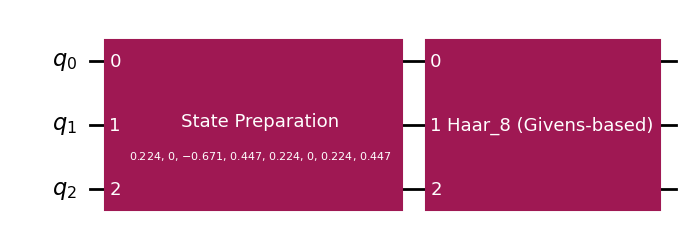

In [4]:
# --- Circuit: StatePreparation then Unitary(W) ---
qc = QuantumCircuit(num_qubits, name="Haar_Givens_Wavelet_8")
qc.append(StatePreparation(y_norm), qc.qubits)
qc.append(UnitaryGate(W, label="Haar_8 (Givens-based)"), qc.qubits)
# This uses matplotlib for nicer visuals inside Jupyter
qc.draw(output='mpl')
plt.savefig("ex03givens.png", dpi=300, bbox_inches="tight")
plt.savefig("ex03givens.pdf", dpi=300, bbox_inches="tight")

plt.show()  # <- show only after saving


# --- Exact simulation via Statevector (no Aer needed) ---
psi = Statevector.from_instruction(qc)   # |W y_norm>

In [5]:
# Recover unnormalized coefficients and remove global phase
Wy = np.asarray(psi.data) * norm_y
phase = np.exp(-1j * np.angle(Wy[0])) if np.abs(Wy[0]) > 1e-12 else 1.0
Wy = Wy * phase
Wy_real = np.real_if_close(Wy)

print("Computed Haar * y:\n", Wy_real)
print("\nExpected:\n", expected)

# Verify numerically
np.testing.assert_allclose(Wy_real, expected, atol=1e-9)
print("\n✅ Match confirmed.")

Computed Haar * y:
 [ 1.41421356 -1.41421356  1.         -1.          0.70710678 -3.53553391
  0.70710678 -0.70710678]

Expected:
 [ 1.41421356 -1.41421356  1.         -1.          0.70710678 -3.53553391
  0.70710678 -0.70710678]

✅ Match confirmed.


 
### **Modular Quantum Givens Rotations**

A *Givens rotation* is a $2\times2$ orthogonal block acting on a pair of coordinates $(i,j)$ inside a larger vector.  
Classically, it has the form  
$$
G(i,j,\theta)
=
\begin{bmatrix}
\ddots &        &        &        & \\
       & \cos\theta & \cdots & -\sin\theta & \\
       & \vdots     & \ddots &  \vdots     & \\
       & \sin\theta & \cdots &  \cos\theta & \\
       &        &        &        & \ddots
\end{bmatrix}.
$$

In quantum computing, a Givens rotation is implemented by  rotating amplitudes between two computational basis states
$\{|i\rangle, |j\rangle\}$ while leaving all other basis states fixed.  
This is the fundamental building block for constructing arbitrary real orthogonal transforms such as Haar, DWT, or custom wavelet matrices.

---

### 1. Identifying the subspace $\{|i\rangle,|j\rangle\}$

Basis states correspond to binary strings (qubit patterns).  
To apply a rotation mixing amplitudes of $|i\rangle$ and $|j\rangle$, we:

1. Find which qubits differ between $i$ and $j$.  
2. Use **Pauli-X** and **CNOT** “routing steps” to move those two states into a simple adjacent pair, usually  
   $$
   |0\ldots0\rangle \quad\text{and}\quad |0\ldots01\rangle.
   $$
3. Apply a single-qubit rotation `RY(θ)` on the target qubit.  
4. Undo the routing to return qubits to their original positions.

This procedure implements a two-level unitary supported only on $\{|i\rangle,|j\rangle\}$.

---

### 2. Two-Level Unitaries From RY 

The basic amplitude-mixing gate is  
$$
\mathrm{RY}(\theta)
=
\begin{bmatrix}
\cos\frac{\theta}{2} & -\sin\frac{\theta}{2} \\
\sin\frac{\theta}{2} &  \cos\frac{\theta}{2}
\end{bmatrix},
$$

which is exactly a **Givens rotation** in the $\{|0\rangle,|1\rangle\}$ subspace.  
When surrounded by the correct controls (CNOTs) it becomes a Givens rotation on *any pair* of basis states.

Thus:

- **Uncontrolled $\mathrm{RY}(\theta)$** = Givens on states differing in the least-significant bit.  
- **Controlled $\mathrm{RY}(\theta)$** = Givens on states differing in a specific bit pattern.  
- **Multi-controlled $\mathrm{RY}(\theta)$** = Givens on a *single pair* of selected basis states.

---

### 3. Modular Construction

A real orthogonal transform (like Haar, multi-resolution $W$, or your QWS transforms) can be built as a **product of Givens rotations**:
$$
W = G_m G_{m-1} \cdots G_1.
$$

Each factor is:

- A rotation angle (derived from the classical transform),  
- A pair of basis states $(i_k,j_k)$ to be mixed,  
- A routing–rotate–unroute pattern made of  
  - X gates  
  - CNOT gates  
  - one $\mathrm{RY}(\theta_k)$ gate.

Because these blocks act on **disjoint 2D subspaces**, they compose cleanly and produce an exact quantum analogue of the classical matrix.

--
### 4. Why This Is Efficient for Wavelets

- Haar and wavelet transforms are sparse and decompose naturally into pairwise mixes.  
- Each stage (coarse, detail-1, detail-2, …) corresponds to a layer of Givens gates.  
- The quantum implementation is shallow and interpretable.  
- The structure aligns with QWS ideas: unitary shrinkage, coherence control, and amplitude mixing.

Thus, the quantum Givens network is the most modular and physically meaningful way to implement classical multiresolution transforms on qubits.


Check W @ y:
W @ y     = [ 1.41421356 -1.41421356  1.         -1.          0.70710678 -3.53553391
  0.70710678 -0.70710678]
Wy_target = [ 1.41421356 -1.41421356  1.         -1.          0.70710678 -3.53553391
  0.70710678 -0.70710678]
Diff      = [0. 0. 0. 0. 0. 0. 0. 0.]

High-level circuit (single W):
     ┌──────────┐
q_0: ┤0         ├
     │          │
q_1: ┤1 Unitary ├
     │          │
q_2: ┤2         ├
     └──────────┘

Decomposed circuit (full quantum Givens style):
global phase: 4.8665
       ┌────────────────────┐         ┌───────────────────┐         ┌────────────────────────┐                                ┌──────────────────────┐          ┌───────────────────┐          ┌────────────────────────┐                                                   ┌────────────────────┐                                                 ┌───────────────────┐         ┌────────────────────────────┐                                                             ┌───────────────────────┐        ┌─────

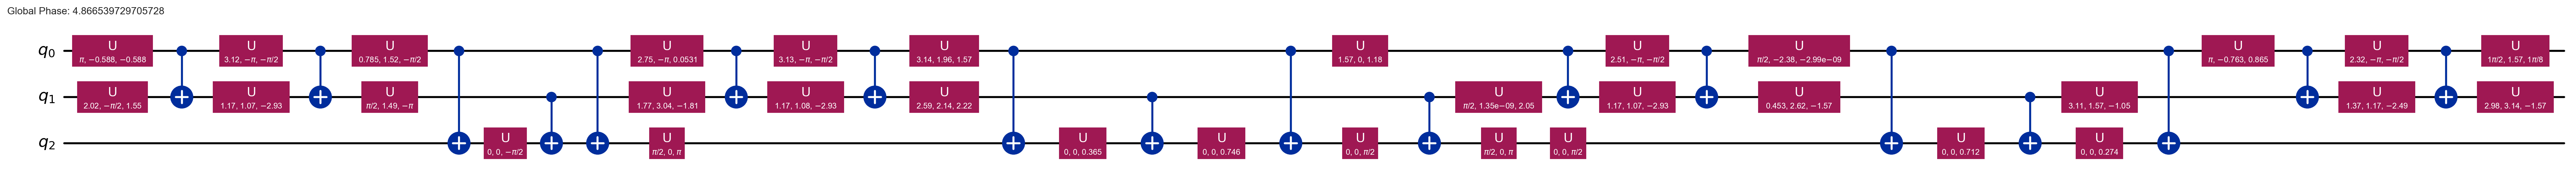

In [5]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 200          # high-resolution plots
plt.rcParams['savefig.dpi'] = 300         # high-resolution when saving
plt.style.use('seaborn-v0_8-whitegrid')   # or "default"
# -------------------------------------------------
# 1. Your classical Haar / multiresolution W
# -------------------------------------------------

def haar3_matrix_8():
    H = np.array([
        [1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1,-1,-1,-1,-1],
        [1, 1,-1,-1, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1,-1,-1],
        [1,-1, 0, 0, 0, 0, 0, 0],
        [0, 0, 1,-1, 0, 0, 0, 0],
        [0, 0, 0, 0, 1,-1, 0, 0],
        [0, 0, 0, 0, 0, 0, 1,-1]
    ], dtype=float)
    return H / np.sqrt(8.0)

# Your classical mapping
y = np.array([1, 0, -3, 2, 1, 0, 1, 2], float)
Wy_target = np.array([
    1.41421356, -1.41421356,  1.        , -1.        ,
    0.70710678, -3.53553391,  0.70710678, -0.70710678
])

# Here I'm reconstructing W as D @ H as before,
# but if you already have W, you can just paste it instead.
H = haar3_matrix_8()
Hy = H @ y
scale = Wy_target / Hy
D = np.diag(scale)
W = D @ H

print("Check W @ y:")
print("W @ y     =", np.round(W @ y, 8))
print("Wy_target =", np.round(Wy_target, 8))
print("Diff      =", np.round(W @ y - Wy_target, 12))

# -------------------------------------------------
# 2. Build a quantum circuit with W and DECOMPOSE it
# -------------------------------------------------

U = Operator(W)     # 8×8 real orthogonal

qc = QuantumCircuit(3, name="W")
qc.unitary(U, [0, 1, 2])

print("\nHigh-level circuit (single W):")
print(qc.draw(fold=-1))

# IMPORTANT: in Qiskit 2.x, just use .decompose() repeatedly instead of transpile
qc_dec = qc.decompose(reps=3)  # expand the UnitaryGate into 1q + CX network

print("\nDecomposed circuit (full quantum Givens style):")
print(qc_dec.draw(fold=-1))

# -------------------------------------------------
# 3. Verify numerically on your y
# -------------------------------------------------
norm_y = np.linalg.norm(y)
y_norm = y / norm_y

psi_in = Statevector(y_norm)
psi_out = psi_in.evolve(qc_dec)

Wy_quantum = psi_out.data * norm_y

print("\nQuantum Wy (from decomposed circuit):")
print(np.round(Wy_quantum, 8))
print("Target Wy_target:")
print(np.round(Wy_target, 8))
print("Difference (quantum - target):")
print(np.round(Wy_quantum - Wy_target, 12))

# -------------------------------------------------
# 4. Plot the circuit
# -------------------------------------------------
qc_dec.draw(output='mpl', fold=-1)
#qc.draw(output='mpl')
plt.savefig("ex03modgivens.png", dpi=300, bbox_inches="tight")
plt.savefig("ex03modgivens.pdf", dpi=300, bbox_inches="tight")

plt.show()
